In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

In [24]:
data_path = "../saved_models/STCRL/embeddings/embedded_trajectories.csv"
#data_path = "../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories.csv"
df = pd.read_csv(data_path)
df.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_sequential', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success', 'trajectory_embedding_multi',
       'trajectory_embedding_weighted_multi'],
      dtype='object')

### Trajectory normalization

In [25]:
import numpy as np
import ast

def normalize_trajectory_3d(trajectory, time_sequence, target_position=np.array([1.0, 0.0])):
    """
    Normalize trajectory spatially while preserving original time.
    
    Args:
        trajectory: numpy array of shape (num_points, 2) containing x,y coordinates
        time_sequence: numpy array of timestamps in milliseconds for each point
        target_position: desired end position for all trajectories (default: [1,0])
    
    Returns:
        Normalized 3D trajectory (x, y, time_in_seconds)
    """
    # Convert time from milliseconds to seconds
    time_sequence_seconds = time_sequence / 1000.0
    
    # Spatial normalization
    start_pos = trajectory[0]
    centered = trajectory - start_pos
    
    # Get current target position after centering
    current_target = centered[-1]
    
    # Calculate rotation angle to align with desired target
    current_angle = np.arctan2(current_target[1], current_target[0])
    desired_angle = np.arctan2(target_position[1], target_position[0])
    rotation_angle = desired_angle - current_angle
    
    # Create rotation matrix
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    rotation_matrix = np.array([[cos_theta, -sin_theta],
                              [sin_theta, cos_theta]])
    
    # Rotate trajectory
    rotated = np.dot(centered, rotation_matrix.T)
    
    # Scale to match target length
    current_length = np.linalg.norm(rotated[-1])
    target_length = np.linalg.norm(target_position)
    scale_factor = target_length / current_length if current_length > 0 else 1
    
    normalized_spatial = rotated * scale_factor
    
    # Create 3D trajectory with time in seconds
    trajectory_3d = np.column_stack((normalized_spatial, time_sequence_seconds))
    
    return trajectory_3d

def normalize_trajectory_sequence_3d(path, time_diff_ms, target_position=np.array([1.0, 0.0]), target_length=512):
    """
    Normalize a trajectory into 3D (x, y, time_in_seconds).
    
    Args:
        path: trajectory coordinates as string or numpy array
        time_diff_ms: time differences in milliseconds
        target_position: desired end position (default: [1,0])
        target_length: desired number of points after resampling (default: 100)
    
    Returns:
        Normalized 3D trajectory with time in seconds
    """
    # Parse input trajectory
    trajectory = np.array(eval(path) if isinstance(path, str) else path)
    
    # Parse time sequence
    time_sequence = np.array(eval(time_diff_ms) if isinstance(time_diff_ms, str) else time_diff_ms)
    
    norm_traj_3d = np.array([])
    
    if isinstance(trajectory, np.ndarray) and trajectory.size > 0 and not np.all(trajectory == 0):
        # Normalize to 3D with time in seconds
        norm_traj_3d = normalize_trajectory_3d(trajectory, time_sequence, target_position)
        
        # Optional resampling (only for spatial coordinates)
        if target_length is not None and target_length > 2:
            t = np.linspace(0, 1, target_length)
            t_original = np.linspace(0, 1, len(norm_traj_3d))
            
            # Resample spatial coordinates
            resampled_spatial = np.vstack([
                np.interp(t, t_original, norm_traj_3d[:, 0]),
                np.interp(t, t_original, norm_traj_3d[:, 1])
            ]).T
            
            # Resample time to maintain correspondence
            resampled_time = np.interp(t, t_original, norm_traj_3d[:, 2])
            
            norm_traj_3d = np.column_stack((resampled_spatial, resampled_time))
    
    return norm_traj_3d

# Example usage:
# normalized_traj = normalize_trajectory_sequence_3d(
#     path=path_data,
#     time_diff_ms=time_diff_ms_data
# )

In [26]:
df["normalized_trajectory"] = df.apply(lambda x: normalize_trajectory_sequence_3d(x['path'], x['time_diff_ms']), axis=1)

### Calculate E-E matrix from Embedded space

In [27]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

def calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi',
                                             distance_metric='euclidean', window_size=6):
    """
    Calculate exploration and exploitation scores for sequential trials.
    Uses a rolling window approach to determine how much a participant is exploring vs exploiting.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing trajectory data with columns:
        - participant_id: to group trials by participant
        - task_type: to separate unimanual (0) and bimanual (1) tasks
        - day, block, trial_no: to order trials chronologically
        - embedding_column: trajectory embeddings
    
    embedding_column : str, default='trajectory_embedding_weighted_multi'
        Column name for the trajectory embeddings to use
    
    distance_metric : str, default='euclidean'
        Distance metric to use for measuring embedding similarities
    
    window_size : int, default=5
        Size of the rolling window to use for calculations
        
    Returns:
    --------
    pandas.DataFrame
        Original dataframe with additional columns:
        - exploration_score: higher values indicate more exploration
        - exploitation_score: higher values indicate more exploitation
    """
    
    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()
    
    # Initialize new columns for scores
    result_df['exploration_score'] = np.nan
    result_df['exploitation_score'] = np.nan
    result_df['novelty'] = np.nan
    result_df['avg_similarity_to_window'] = np.nan
    result_df['max_similarity_to_window'] = np.nan
    result_df['trial_seq'] = np.nan
    
    # Ensure embedding column is in numpy array format
    if isinstance(result_df[embedding_column].iloc[0], str):
        # Parse string embeddings properly
        result_df[embedding_column] = result_df[embedding_column].apply(
            lambda x: np.array([float(val) for val in x.strip('[]').split()]) if isinstance(x, str) else x
        )
    
    # Group by participant and task_type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically for this participant and task
        group_df = group_df.sort_values(by=['session_no', 'trial_no'])
        # group_df = group_df.reset_index(drop=True)
        
        # Create a sequence number for trials
        group_df['trial_seq'] = range(1, len(group_df) + 1)
        
        # Store sequence number in the result dataframe
        result_df.loc[group_df.index, 'trial_seq'] = group_df['trial_seq'].values
        
        # Handle missing embeddings by creating placeholder embeddings
        valid_embedding_indices = []
        valid_embeddings = []
        embedding_dim = None
        
        # First pass to identify valid embeddings and determine dimension
        for i, idx in enumerate(group_df.index):
            embedding = group_df.loc[idx, embedding_column]
            if embedding is not None and not (isinstance(embedding, float) and np.isnan(embedding)):
                if embedding_dim is None and hasattr(embedding, 'shape'):
                    embedding_dim = embedding.shape[0]
                valid_embedding_indices.append(i)
                valid_embeddings.append(embedding)
        
        # If we have no valid embeddings or couldn't determine dimension, skip this group
        if not valid_embeddings or embedding_dim is None:
            print(f"Warning: No valid embeddings for participant {participant_id}, task {task_type}")
            continue
        
        # Second pass to process distances only for valid embeddings
        if valid_embeddings:
            # Create array of valid embeddings
            valid_embeddings_array = np.vstack(valid_embeddings)
            
            # Calculate distances between valid embeddings
            valid_distances = cdist(valid_embeddings_array, valid_embeddings_array, metric=distance_metric)
            
            # Create a full distance matrix with NaNs for missing embeddings
            n_trials = len(group_df)
            all_distances = np.full((n_trials, n_trials), np.nan)
            
            # Fill in distances for valid embeddings
            for i, valid_i in enumerate(valid_embedding_indices):
                for j, valid_j in enumerate(valid_embedding_indices):
                    all_distances[valid_i, valid_j] = valid_distances[i, j]
            
            # Calculate scores for each trial in sequence
            for i, idx in enumerate(group_df.index):
                # For the first trial, set default values
                if i == 0:
                    result_df.loc[idx, 'exploration_score'] = 1.0
                    result_df.loc[idx, 'exploitation_score'] = 0.0
                    result_df.loc[idx, 'novelty'] = 1.0
                    result_df.loc[idx, 'avg_similarity_to_window'] = 0.0
                    result_df.loc[idx, 'max_similarity_to_window'] = 0.0
                    continue
                
                # Skip calculation if current trial has missing embedding
                if i not in valid_embedding_indices:
                    # Assign the mean or a default value for missing embeddings
                    if i > 0:
                        # Use the mean of previous valid scores as a fallback
                        valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                        valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                        
                        if len(valid_exploration_scores) > 0:
                            result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                        else:
                            result_df.loc[idx, 'exploration_score'] = 0.5  # Default
                            
                        if len(valid_exploitation_scores) > 0:
                            result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                        else:
                            result_df.loc[idx, 'exploitation_score'] = 0.5  # Default
                    
                    # Set other metrics to NaN or default values
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    continue
                
                # Filter out NaN values from distances to previous trials
                distances_to_previous = all_distances[i, :i]
                valid_previous_distances = distances_to_previous[~np.isnan(distances_to_previous)]
                
                if len(valid_previous_distances) > 0:
                    # Novelty: minimum distance to any previous trial
                    # Higher value means more different (more novel)
                    novelty = np.min(valid_previous_distances)
                    result_df.loc[idx, 'novelty'] = novelty
                    
                    # For window calculations, get start index
                    window_start = max(0, i - window_size)
                    
                    # Calculate distances to the window of previous trials
                    distances_to_window = all_distances[i, window_start:i]
                    valid_window_distances = distances_to_window[~np.isnan(distances_to_window)]
                    
                    if len(valid_window_distances) > 0:
                        # Convert distances to similarities (higher = more similar)
                        similarities_to_window = 1 / (1 + valid_window_distances)
                        
                        # Average similarity to window (measure of exploitation)
                        avg_similarity = np.mean(similarities_to_window)
                        result_df.loc[idx, 'avg_similarity_to_window'] = avg_similarity
                        
                        # Maximum similarity to any trial in window (measure of exploitation)
                        max_similarity = np.max(similarities_to_window)
                        result_df.loc[idx, 'max_similarity_to_window'] = max_similarity
                        
                        # Alternative exploration score: based on novelty (difference from previous trials)
                        # Normalize to keep early trials' scores high
                        trial_position_factor = np.exp(-0.01 * i)  # Decreases slowly with trial number
                        exploration_score = novelty * (0.7 + 0.3 * trial_position_factor)
                        
                        # Alternative exploitation score: based on similarity to window
                        # We use max similarity as the primary factor
                        exploitation_score = max_similarity
                        # print(participant_id, idx, exploration_score, exploitation_score)
                        result_df.loc[idx, 'exploration_score'] = exploration_score
                        result_df.loc[idx, 'exploitation_score'] = exploitation_score
                    else:
                        # No valid window distances
                        result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                        result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                        
                        # Use default values or interpolate from other trials
                        if i > 1:
                            # Use mean of previous scores
                            valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                            valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                            
                            if len(valid_exploration_scores) > 0:
                                result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                            else:
                                result_df.loc[idx, 'exploration_score'] = 0.5
                                
                            if len(valid_exploitation_scores) > 0:
                                result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                            else:
                                result_df.loc[idx, 'exploitation_score'] = 0.5
                else:
                    # No valid previous distances, set defaults
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'exploration_score'] = 0.5  # Default mid-point
                    result_df.loc[idx, 'exploitation_score'] = 0.5  # Default mid-point
    
    # Normalize scores to [0,1] range
    for score_col in ['exploration_score', 'exploitation_score']:
        min_val = result_df[score_col].min()
        max_val = result_df[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            result_df[score_col] = (result_df[score_col] - min_val) / (max_val - min_val)
    
    # Add task labels
    result_df['task_label'] = result_df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    return result_df

def calculate_exploration_exploitation_ratio(df, smoothing=0.01):
    """
    Calculate exploration/exploitation ratio for each trial.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration_score and exploitation_score columns
    
    smoothing : float, default=0.01
        Small value to avoid division by zero
    
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional column:
        - exploration_exploitation_ratio: ratio of exploration to exploitation
    """
    result_df = df.copy()
    
    # Calculate ratio (with smoothing to avoid division by zero)
    result_df['exploration_exploitation_ratio'] = (
        result_df['exploration_score'] / (result_df['exploitation_score'] + smoothing)
    )
    
    return result_df

def calculate_progression_metrics(df):
    """
    Calculate progression metrics based on sequential trial analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration and exploitation scores
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional progression metrics
    """
    result_df = df.copy()
    
    # Initialize columns
    result_df['learning_rate'] = np.nan
    result_df['strategy_stability'] = np.nan
    
    # Process each participant and task type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically 
        group_df = group_df.sort_values(by=['trial_seq'])
        
        # Get indices for this group
        indices = group_df.index
        
        # Skip if too few trials
        if len(indices) < 10:  # Need enough trials for meaningful metrics
            continue
            
        # Calculate rolling metrics
        window_size = min(5, len(indices) // 4)  # Adaptive window size
        
        for i in range(window_size, len(indices)):
            current_idx = indices[i]
            
            # Get window of previous trials
            window_indices = indices[i-window_size:i]
            window_df = group_df.loc[window_indices]
            
            # Calculate learning rate: change in performance over trials
            # Use whichever performance metrics are available
            if 'rmsd' in group_df.columns:
                # Negative learning rate because lower rmsd is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['rmsd'], 1)[0]
            elif 'completion_time' in group_df.columns:
                # Negative learning rate because lower time is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['completion_time'], 1)[0]
            else:
                # Default to exploitation trend if no performance metrics
                learning_rate = np.polyfit(window_df['trial_seq'], window_df['exploitation_score'], 1)[0]
            
            result_df.loc[current_idx, 'learning_rate'] = learning_rate
            
            # Strategy stability: consistency of exploration/exploitation ratio
            if 'exploration_exploitation_ratio' in window_df.columns:
                strategy_stability = 1 / (1 + window_df['exploration_exploitation_ratio'].std())
                result_df.loc[current_idx, 'strategy_stability'] = strategy_stability
    
    return result_df

In [28]:
#df_with_scores = calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_multi_loss')
df_with_scores = calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi')
df_with_ratio = calculate_exploration_exploitation_ratio(df_with_scores)
df_with_ratio_progress =calculate_progression_metrics(df_with_ratio)
df_with_ratio_progress

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,0.082055,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,8.205542,NaN,NaN
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,0.112268,0.421532,1.372298,0.421532,0.421532,2.0,Unimanual,0.260162,NaN,NaN
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,0.059388,0.578677,0.728079,0.516601,0.578677,3.0,Unimanual,0.100884,NaN,NaN
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,0.059665,0.576824,0.733632,0.501828,0.576824,4.0,Unimanual,0.101674,NaN,NaN
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,0.015491,0.839610,0.191029,0.585121,0.839610,5.0,Unimanual,0.018233,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,MTRLRN079,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,0.017954,0.721609,0.275226,0.617692,0.721609,116.0,Bimanual,0.024540,-101.055825,0.987909
16316,MTRLRN079,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,0.006610,0.838702,0.101455,0.705284,0.838701,117.0,Bimanual,0.007789,-73.719668,0.989142
16317,MTRLRN079,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,0.016737,0.777017,0.257179,0.674807,0.777016,118.0,Bimanual,0.021266,2.003748,0.989531
16318,MTRLRN079,5,1,23,Day-3,Block-1,0,0,559.127069,355.643316,...,0.017366,0.586678,0.267157,0.501319,0.586678,119.0,Bimanual,0.029104,34.007860,0.989642


### Comparison of Exploration-Exploitation (E-E) Ratios: Normalized Trajectories vs Embedding Space
We compute E-E ratios from two representations: (1) learned trajectory embeddings and (2) purely geometric normalized trajectories. This allows assessing whether embeddings capture higher-order control strategies beyond geometric variability.

In [29]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def _flatten_normalized_spatial(traj_3d):
    """Flatten spatial (x,y) coordinates of a normalized trajectory into 1D vector.
    Accepts array shape (N,3) with columns (x,y,time_seconds). Returns None if invalid."""
    if traj_3d is None or isinstance(traj_3d, float) and np.isnan(traj_3d):
        return None
    arr = np.array(traj_3d)
    if arr.ndim != 2 or arr.shape[1] < 2 or arr.size == 0:
        return None
    spatial = arr[:, :2]  # take x,y
    return spatial.flatten()

def calculate_exploration_exploitation_scores_normalized(df, normalized_column='normalized_trajectory',
                                                         window_size=6, distance_metric='euclidean'):
    """Compute exploration & exploitation scores using normalized spatial trajectories.
    For each participant/task, trajectories are flattened (x,y) and pairwise distances computed.

    exploration_score: novelty (min distance to any previous) adjusted for trial position
    exploitation_score: max similarity (1/(1+distance)) to window of recent trials
    Returns original df with new columns:
        exploration_score_traj, exploitation_score_traj, exploration_exploitation_ratio_traj
    """
    result_df = df.copy()
    result_df['exploration_score_traj'] = np.nan
    result_df['exploitation_score_traj'] = np.nan
    result_df['exploration_exploitation_ratio_traj'] = np.nan
    result_df['traj_valid'] = False
    
    # Pre-flatten trajectories
    flattened = df[normalized_column].apply(_flatten_normalized_spatial)
    result_df['flattened_traj_vec'] = flattened
    
    # Group by participant/task (infer columns if present)
    group_cols = [c for c in ['participant_id','task_type'] if c in result_df.columns]
    if not group_cols:
        group_cols = []  # treat whole set as one group if metadata absent
    
    def process_group(g):
        g = g.sort_values(by=[col for col in ['session_no','trial_no','trial_seq'] if col in g.columns])
        # Build list of valid vectors
        vecs = []
        valid_idx_map = {}
        for i, idx in enumerate(g.index):
            v = g.at[idx,'flattened_traj_vec']
            if v is not None and len(v)>0 and not np.all(np.isnan(v)):
                vecs.append(v)
                valid_idx_map[i] = len(vecs)-1
                result_df.at[idx,'traj_valid'] = True
        if not vecs:
            return
        # Pad shorter vectors to max length (ensures same dimension)
        max_len = max(len(v) for v in vecs)
        vecs_padded = np.vstack([np.pad(v,(0,max_len-len(v)),'constant') for v in vecs])
        dist_mat_valid = cdist(vecs_padded, vecs_padded, metric=distance_metric)
        # Iterate trials
        for i, idx in enumerate(g.index):
            if i == 0:
                result_df.at[idx,'exploration_score_traj'] = 1.0
                result_df.at[idx,'exploitation_score_traj'] = 0.0
                result_df.at[idx,'exploration_exploitation_ratio_traj'] = 1.0
                continue
            if i not in valid_idx_map:
                # fallback: use mean of previous valid scores
                prev = result_df.loc[g.index[:i], 'exploration_score_traj'].dropna()
                result_df.at[idx,'exploration_score_traj'] = prev.mean() if len(prev)>0 else 0.5
                prev2 = result_df.loc[g.index[:i], 'exploitation_score_traj'].dropna()
                result_df.at[idx,'exploitation_score_traj'] = prev2.mean() if len(prev2)>0 else 0.5
                result_df.at[idx,'exploration_exploitation_ratio_traj'] = result_df.at[idx,'exploration_score_traj'] / (result_df.at[idx,'exploitation_score_traj'] + 1e-3)
                continue
            valid_i = valid_idx_map[i]
            prev_valid_indices = [valid_idx_map[j] for j in range(i) if j in valid_idx_map]
            if not prev_valid_indices:
                continue
            distances_to_prev = dist_mat_valid[valid_i, prev_valid_indices]
            novelty = np.min(distances_to_prev)
            window_start = max(0, i - window_size)
            window_range = list(range(window_start, i))
            window_valid = [valid_idx_map[j] for j in window_range if j in valid_idx_map]
            if window_valid:
                distances_window = dist_mat_valid[valid_i, window_valid]
                similarities = 1/(1+distances_window)
                max_similarity = np.max(similarities)
                # Trial position modulation (slight decay)
                trial_position_factor = np.exp(-0.01 * i)
                exploration_score = novelty * (0.7 + 0.3 * trial_position_factor)
                exploitation_score = max_similarity
            else:
                exploration_score = novelty
                exploitation_score = 0.5
            result_df.at[idx,'exploration_score_traj'] = exploration_score
            result_df.at[idx,'exploitation_score_traj'] = exploitation_score
            result_df.at[idx,'exploration_exploitation_ratio_traj'] = exploration_score / (exploitation_score + 1e-3)
    
    if group_cols:
        for _, g in result_df.groupby(group_cols):
            process_group(g)
    else:
        process_group(result_df)
    
    # Normalize scores to [0,1] if possible
    for c in ['exploration_score_traj','exploitation_score_traj']:
        mn = result_df[c].min()
        mx = result_df[c].max()
        if pd.notna(mn) and pd.notna(mx) and mx > mn:
            result_df[c] = (result_df[c]-mn)/(mx-mn)
    return result_df

# Generate trajectory-based E-E scores
df_traj_scores = calculate_exploration_exploitation_scores_normalized(df)
traj_ratio_available = df_traj_scores['exploration_exploitation_ratio_traj'].notna().sum()
print(f'Trajectory-based E-E ratio available for {traj_ratio_available} trials.')

# Merge embedding-based ratio (already computed earlier as df_with_ratio) with trajectory-based
comparison_cols = ['participant_id','task_type','session_no','trial_no']
merge_keys = [c for c in comparison_cols if c in df_with_ratio.columns and c in df_traj_scores.columns]
if not merge_keys:
    df_compare = pd.DataFrame()
    print('No common keys for merge; cannot compare.')
else:
    df_compare = pd.merge(df_with_ratio,
                       df_traj_scores[['exploration_exploitation_ratio_traj'] + merge_keys],
                       on=merge_keys, how='inner')
    print('Merged shape:', df_compare.shape)
    display(df_compare.head())

Trajectory-based E-E ratio available for 16320 trials.
Merged shape: (16320, 44)


,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,trajectory_embedding_weighted_multi,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,exploration_exploitation_ratio_traj
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,"[0.19598372, -0.0443047, -0.39139536, -0.03888...",0.082055,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,8.205542,1.000000
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,"[0.16557111, 0.21644062, -0.37040448, 0.631607...",0.112268,0.421532,1.372298,0.421532,0.421532,2.0,Unimanual,0.260162,628.181745
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,"[0.26427168, 0.016123265, -0.27471226, 0.03697...",0.059388,0.578677,0.728079,0.516601,0.578677,3.0,Unimanual,0.100884,172.860092
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,"[0.238517419, -0.000704005361, -0.214667365, 0...",0.059665,0.576824,0.733632,0.501828,0.576824,4.0,Unimanual,0.101674,75.758626
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,"[0.2107846, -0.07058901, -0.39435142, -0.05100...",0.015491,0.839610,0.191029,0.585121,0.839610,5.0,Unimanual,0.018233,7.127018


### Bootstrap Comparison: Hypotheses 1a & 1b (Embedding vs Trajectory E-E Ratios)
We perform participant-level bootstrapping (sampling 10 Term and 10 Preterm participants per iteration) to estimate:
1. Early (sessions 1–3) vs Late (session 5) shift in E-E ratio (Hypothesis 1a)
2. Preterm vs Term difference in bimanual task E-E ratio (Hypothesis 1b)

Representations:
- Embedding-based E-E ratio: `exploration_exploitation_ratio`
- Trajectory-based E-E ratio: `exploration_exploitation_ratio_traj`

Outputs (per representation):
- Mean Early, Mean Late, Mean Difference (Early - Late) with 95% CI
- Mean Preterm, Mean Term (bimanual), Difference (Preterm - Term) with 95% CI

Method:
- For each bootstrap iteration:
  - Sample (with replacement if necessary) up to 10 unique Term and 10 unique Preterm participants.
  - Compute per-participant phase means; aggregate Early vs Late.
  - Compute per-participant bimanual overall mean ratios; aggregate cohort difference.
- 95% CI = 2.5th and 97.5th percentiles of bootstrap distribution.


Available Term participants: 50; Preterm participants: 18
=== Bootstrap Results (Mean Difference ±95% CI) ===
Hypothesis 1a: Early - Late (Embedding): 0.1503 [0.1329, 0.1680] (n=1000)
Hypothesis 1a: Early - Late (Trajectory): 162.7077 [1.7914, 441.7271] (n=1000)
Hypothesis 1b: Preterm - Term Bimanual (Embedding): 0.0075 [-0.0229, 0.0337] (n=1000)
Hypothesis 1b: Preterm - Term Bimanual (Trajectory): -274.7518 [-1169.2366, 112.5961] (n=1000)


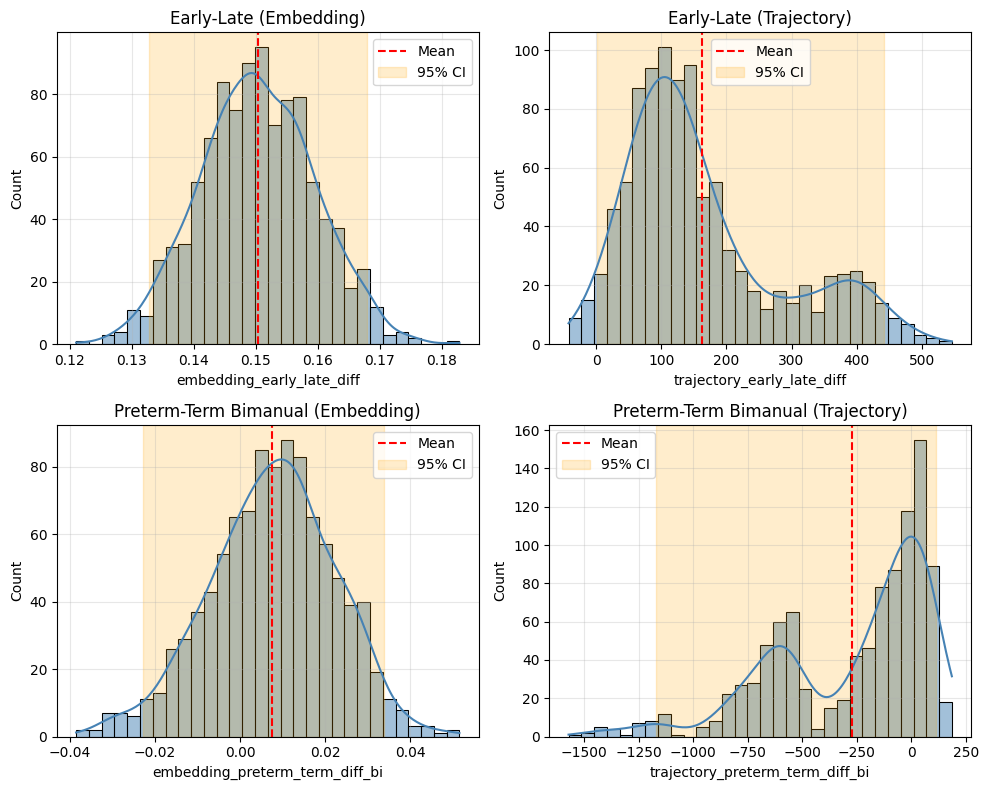

In [32]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- Bootstrap configuration ---
N_BOOT = 1000  # adjust if needed
SAMPLE_TERM = 10
SAMPLE_PRETERM = 10
EARLY_SESSIONS = {1,2,3}
LATE_SESSION = {5}

REQUIRED_COLS = [
    'participant_id','Cohort','session_no','task_type',
    'exploration_exploitation_ratio','exploration_exploitation_ratio_traj'
]

# Validate data availability
if 'df_compare' not in globals() or df_compare is None or df_compare.empty:
    raise RuntimeError('df_compare not available; run earlier cells to build comparison dataframe.')

work_df = df_compare.copy()

# Ensure cohort present (attempt attach if missing)
if 'Cohort' not in work_df.columns:
    print('Cohort column missing; attempting to attach.')
    try:
        # Reuse attach_cohort if defined earlier
        work_df = attach_cohort(work_df) if 'attach_cohort' in globals() else work_df
    except Exception as e:
        print('Failed to attach cohort:', e)

missing = [c for c in REQUIRED_COLS if c not in work_df.columns]
if missing:
    raise RuntimeError(f'Missing required columns for bootstrap: {missing}')

# Filter to rows with valid ratios
work_df = work_df.dropna(subset=['exploration_exploitation_ratio','exploration_exploitation_ratio_traj','session_no','Cohort'])

# Map cohort labels to canonical Term / Preterm
def cohort_label(c):
    c_lower = str(c).lower()
    if 'pre' in c_lower:
        return 'Preterm'
    if 'term' in c_lower:
        return 'Term'
    return None
work_df['CohortCanonical'] = work_df['Cohort'].apply(cohort_label)
work_df = work_df.dropna(subset=['CohortCanonical'])

# Collect participant lists
term_participants = work_df.loc[work_df['CohortCanonical']=='Term','participant_id'].unique().tolist()
preterm_participants = work_df.loc[work_df['CohortCanonical']=='Preterm','participant_id'].unique().tolist()
print(f'Available Term participants: {len(term_participants)}; Preterm participants: {len(preterm_participants)}')

if len(term_participants) == 0 or len(preterm_participants) == 0:
    raise RuntimeError('Insufficient participants for both cohorts; cannot bootstrap.')

# Helper: compute per-participant phase means for given ratio column
def participant_phase_means(df, ratio_col):
    sub = df[['participant_id','session_no',ratio_col,'task_type','CohortCanonical']].copy()
    # Early mean: sessions 1,2,3; Late mean: session 5; Mid (optional) session 4
    early = sub[sub['session_no'].isin(EARLY_SESSIONS)].groupby('participant_id')[ratio_col].mean()
    late = sub[sub['session_no'].isin(LATE_SESSION)].groupby('participant_id')[ratio_col].mean()
    return early, late

# Helper: bimanual (task_type==1) overall mean per participant
def bimanual_means(df, ratio_col):
    bi = df[df['task_type']==1]
    return bi.groupby(['participant_id','CohortCanonical'])[ratio_col].mean()

# Bootstrap containers
boot_results = {
    'embedding_early_late_diff': [],
    'trajectory_early_late_diff': [],
    'embedding_preterm_term_diff_bi': [],
    'trajectory_preterm_term_diff_bi': []
}

rng = np.random.default_rng(42)

for b in range(N_BOOT):
    # Sample participants (with replacement if fewer than requested)
    sampled_term = rng.choice(term_participants, size=min(SAMPLE_TERM, len(term_participants)), replace=len(term_participants)<SAMPLE_TERM)
    sampled_preterm = rng.choice(preterm_participants, size=min(SAMPLE_PRETERM, len(preterm_participants)), replace=len(preterm_participants)<SAMPLE_PRETERM)
    sampled_ids = np.concatenate([sampled_term, sampled_preterm])
    sample_df = work_df[work_df['participant_id'].isin(sampled_ids)]

    # Early vs Late embedding
    emb_early, emb_late = participant_phase_means(sample_df, 'exploration_exploitation_ratio')
    # Align idx intersection
    common_emb = emb_early.index.intersection(emb_late.index)
    if len(common_emb) >= 3:
        boot_results['embedding_early_late_diff'].append((emb_early.loc[common_emb] - emb_late.loc[common_emb]).mean())
    else:
        boot_results['embedding_early_late_diff'].append(np.nan)

    # Early vs Late trajectory
    traj_early, traj_late = participant_phase_means(sample_df, 'exploration_exploitation_ratio_traj')
    common_traj = traj_early.index.intersection(traj_late.index)
    if len(common_traj) >= 3:
        boot_results['trajectory_early_late_diff'].append((traj_early.loc[common_traj] - traj_late.loc[common_traj]).mean())
    else:
        boot_results['trajectory_early_late_diff'].append(np.nan)

    # Bimanual cohort difference embedding
    emb_bi = bimanual_means(sample_df, 'exploration_exploitation_ratio')
    if not emb_bi.empty:
        pre_mean = emb_bi.xs('Preterm', level='CohortCanonical', drop_level=False).mean() if 'Preterm' in emb_bi.index.get_level_values('CohortCanonical') else np.nan
        term_mean = emb_bi.xs('Term', level='CohortCanonical', drop_level=False).mean() if 'Term' in emb_bi.index.get_level_values('CohortCanonical') else np.nan
        boot_results['embedding_preterm_term_diff_bi'].append(pre_mean - term_mean if pd.notna(pre_mean) and pd.notna(term_mean) else np.nan)
    else:
        boot_results['embedding_preterm_term_diff_bi'].append(np.nan)

    # Bimanual cohort difference trajectory
    traj_bi = bimanual_means(sample_df, 'exploration_exploitation_ratio_traj')
    if not traj_bi.empty:
        pre_mean_t = traj_bi.xs('Preterm', level='CohortCanonical', drop_level=False).mean() if 'Preterm' in traj_bi.index.get_level_values('CohortCanonical') else np.nan
        term_mean_t = traj_bi.xs('Term', level='CohortCanonical', drop_level=False).mean() if 'Term' in traj_bi.index.get_level_values('CohortCanonical') else np.nan
        boot_results['trajectory_preterm_term_diff_bi'].append(pre_mean_t - term_mean_t if pd.notna(pre_mean_t) and pd.notna(term_mean_t) else np.nan)
    else:
        boot_results['trajectory_preterm_term_diff_bi'].append(np.nan)

# Convert to DataFrame for summary
boot_df = pd.DataFrame({k: pd.Series(v) for k,v in boot_results.items()})

def summary_stats(series):
    s = series.dropna()
    if len(s)==0:
        return {'mean':np.nan,'ci_low':np.nan,'ci_high':np.nan,'n':0}
    return {
        'mean': s.mean(),
        'ci_low': np.percentile(s, 2.5),
        'ci_high': np.percentile(s, 97.5),
        'n': len(s)
    }

summary = {k: summary_stats(boot_df[k]) for k in boot_df.columns}

print('=== Bootstrap Results (Mean Difference ±95% CI) ===')
print('Hypothesis 1a: Early - Late (Embedding): {mean:.4f} [{ci_low:.4f}, {ci_high:.4f}] (n={n})'.format(**summary['embedding_early_late_diff']))
print('Hypothesis 1a: Early - Late (Trajectory): {mean:.4f} [{ci_low:.4f}, {ci_high:.4f}] (n={n})'.format(**summary['trajectory_early_late_diff']))
print('Hypothesis 1b: Preterm - Term Bimanual (Embedding): {mean:.4f} [{ci_low:.4f}, {ci_high:.4f}] (n={n})'.format(**summary['embedding_preterm_term_diff_bi']))
print('Hypothesis 1b: Preterm - Term Bimanual (Trajectory): {mean:.4f} [{ci_low:.4f}, {ci_high:.4f}] (n={n})'.format(**summary['trajectory_preterm_term_diff_bi']))

# Plot distributions
fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_map = [
    ('embedding_early_late_diff','Early-Late (Embedding)'),
    ('trajectory_early_late_diff','Early-Late (Trajectory)'),
    ('embedding_preterm_term_diff_bi','Preterm-Term Bimanual (Embedding)'),
    ('trajectory_preterm_term_diff_bi','Preterm-Term Bimanual (Trajectory)')
]
for ax,(col,title) in zip(axes.flat, plot_map):
    s = boot_df[col].dropna()
    if len(s)>0:
        sns.histplot(s, bins=30, kde=True, ax=ax, color='steelblue')
        ax.axvline(summary[col]['mean'], color='red', linestyle='--', label='Mean')
        ax.axvspan(summary[col]['ci_low'], summary[col]['ci_high'], color='orange', alpha=0.2, label='95% CI')
        ax.set_title(title)
        ax.legend()
    else:
        ax.set_title(title + ' (no data)')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Store summary for potential downstream use
bootstrap_summary_h1 = summary


In [35]:
# Save bootstrap distribution figure as PNG
import os, datetime
out_dir = 'plots'
os.makedirs(out_dir, exist_ok=True)

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'bootstrap_EE_distributions_{timestamp}.png'

if 'fig' in globals() and fig is not None:
    try:
        fig.savefig(os.path.join(out_dir, filename), dpi=300, bbox_inches='tight')
        print(f'Saved bootstrap distribution figure to {out_dir}/{filename}')
    except Exception as e:
        print('Failed to save existing figure, regenerating:', e)
        # Regenerate and save
        fig, axes = plt.subplots(2,2, figsize=(10,8))
        plot_map = [
            ('embedding_early_late_diff','Early-Late (Embedding)'),
            ('trajectory_early_late_diff','Early-Late (Trajectory)'),
            ('embedding_preterm_term_diff_bi','Preterm-Term Bimanual (Embedding)'),
            ('trajectory_preterm_term_diff_bi','Preterm-Term Bimanual (Trajectory)')
        ]
        for ax,(col,title) in zip(axes.flat, plot_map):
            s = boot_df[col].dropna()
            if len(s)>0:
                sns.histplot(s, bins=30, kde=True, ax=ax, color='steelblue')
                ax.axvline(bootstrap_summary_h1[col]['mean'], color='red', linestyle='--', label='Mean')
                ax.axvspan(bootstrap_summary_h1[col]['ci_low'], bootstrap_summary_h1[col]['ci_high'], color='orange', alpha=0.2, label='95% CI')
                ax.set_title(title)
                ax.legend()
            else:
                ax.set_title(title + ' (no data)')
            ax.grid(alpha=0.3)
        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, filename), dpi=300, bbox_inches='tight')
        print(f'Regenerated and saved bootstrap distribution figure to {out_dir}/{filename}')
else:
    print('Figure variable "fig" not found; regenerating before saving.')
    fig, axes = plt.subplots(2,2, figsize=(10,8))
    plot_map = [
        ('embedding_early_late_diff','Early-Late (Embedding)'),
        ('trajectory_early_late_diff','Early-Late (Trajectory)'),
        ('embedding_preterm_term_diff_bi','Preterm-Term Bimanual (Embedding)'),
        ('trajectory_preterm_term_diff_bi','Preterm-Term Bimanual (Trajectory)')
    ]
    for ax,(col,title) in zip(axes.flat, plot_map):
        s = boot_df[col].dropna()
        if len(s)>0:
            sns.histplot(s, bins=30, kde=True, ax=ax, color='steelblue')
            ax.axvline(bootstrap_summary_h1[col]['mean'], color='red', linestyle='--', label='Mean')
            ax.axvspan(bootstrap_summary_h1[col]['ci_low'], bootstrap_summary_h1[col]['ci_high'], color='orange', alpha=0.2, label='95% CI')
            ax.set_title(title)
            ax.legend()
        else:
            ax.set_title(title + ' (no data)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, filename), dpi=300, bbox_inches='tight')
    print(f'Regenerated and saved bootstrap distribution figure to {out_dir}/{filename}')

Saved bootstrap distribution figure to plots/bootstrap_EE_distributions_20251123_043642.png
